# NeuroSegment-BraTS: Pipeline de Pré-processamento e Adaptação

**Notebook 3:** Pré-processamento e Adaptação dos Dados (Módulo MONAI)

Nesta etapa, construímos o pipeline que converte os dados médicos brutos (Volumes NIfTI 3D) em tensores otimizados para o treinamento de redes neurais profundas. 
Utilizamos a biblioteca **MONAI** (Medical Open Network for AI) para aplicar transformações espaciais e de intensidade, mitigando os problemas estruturais (como o excesso de fundo) e o desbalanceamento de classes identificados na Análise Descritiva.

## 1. Mapeamento dos Dados
A primeira tarefa é varrer o diretório bruto e organizar as 4 modalidades de ressonância (FLAIR, T1, T1ce, T2) em um único bloco lógico ("image") associado à sua respectiva máscara de gabarito ("label").

In [1]:
import os
import glob
import torch
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd,
    CropForegroundd, NormalizeIntensityd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, ToTensord
)
from monai.data import CacheDataset, DataLoader, Dataset

# 1. Caminho para os dados brutos
DATA_PATH = '../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

patient_folders = sorted(glob.glob(os.path.join(DATA_PATH, "BraTS20_Training_*")))

data_dicts = []

for folder in patient_folders:
    patient_id = os.path.basename(folder)
    
    # Agrupando as 4 modalidades em uma lista para formarem 4 canais da mesma imagem
    img_list = [
        os.path.join(folder, f"{patient_id}_flair.nii"),
        os.path.join(folder, f"{patient_id}_t1.nii"),
        os.path.join(folder, f"{patient_id}_t1ce.nii"),
        os.path.join(folder, f"{patient_id}_t2.nii")
    ]
    label_path = os.path.join(folder, f"{patient_id}_seg.nii")
    
    # Só adiciona se todos os arquivos existirem
    if all(os.path.exists(f) for f in img_list) and os.path.exists(label_path):
        data_dicts.append({"image": img_list, "label": label_path})

print(f"Total de pacientes mapeados: {len(data_dicts)}")

# Dividindo os dados (Exemplo simples: 80% Treino, 20% Validação)
train_files, val_files = data_dicts[:-40], data_dicts[-40:]
print(f"Treino: {len(train_files)} pacientes | Validação: {len(val_files)} pacientes")

Total de pacientes mapeados: 368
Treino: 328 pacientes | Validação: 40 pacientes


## 2. Definição do Pipeline de Transformações (MONAI)

Conforme exigido na Etapa 5 do projeto, aplicamos as seguintes transformações, justificando sua escolha:

1. **`CropForegroundd`:** Remove o excesso de fundo preto ao redor do cérebro. *Justificativa:* Economiza memória e foca a rede apenas no tecido real.
2. **`NormalizeIntensityd`:** Aplica normalização (Z-score) apenas nas áreas não nulas (cérebro). *Justificativa:* As ressonâncias possuem escalas de brilho variáveis; a normalização estabiliza o gradiente durante o treinamento.
3. **`RandCropByPosNegLabeld`:** *Feature Engineering Espacial.* Em vez de treinar com a imagem inteira (o que estouraria a VRAM), extraímos "patches" (blocos 3D de 96x96x96). *Justificativa:* Controlamos a taxa de `pos=1` e `neg=1`, forçando a rede a ver blocos contendo tumor com a mesma frequência que vê blocos apenas com cérebro saudável. Isso resolve o problema crítico de **desbalanceamento** detectado no Notebook 2.

In [2]:
# Definindo as chaves do dicionário que criamos lá em cima
keys = ["image", "label"]

# Transformações de Treinamento (Com Data Augmentation)
train_transforms = Compose(
    [
        # Carrega a imagem e a máscara
        LoadImaged(keys=keys),
        # Garante que os canais fiquem na ordem correta para o PyTorch (Canais, X, Y, Z)
        EnsureChannelFirstd(keys=keys),
        # Padroniza a resolução física do voxel
        Spacingd(keys=keys, pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
        # Ajusta a orientação anatômica
        Orientationd(keys=keys, axcodes="RAS"),
        # CORTA O FUNDO PRETO!
        CropForegroundd(keys=keys, source_key="image"),
        # Normaliza apenas a imagem (a máscara não se normaliza, ela é categórica: 0, 1, 2, 4)
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        
        # O MILAGRE DO BALANCEAMENTO: Sorteia blocos 3D focados no tumor
        RandCropByPosNegLabeld(
            keys=keys,
            label_key="label",
            spatial_size=(96, 96, 96), # Tamanho do bloco que vai para a GPU
            pos=1, # Peso para blocos COM tumor
            neg=1, # Peso para blocos SEM tumor
            num_samples=4, # Extrai 4 blocos por paciente por época
            image_key="image",
            image_threshold=0,
        ),
        
        # Data Augmentation: Vira e gira os blocos aleatoriamente
        RandFlipd(keys=keys, spatial_axis=[0], prob=0.10),
        RandFlipd(keys=keys, spatial_axis=[1], prob=0.10),
        RandFlipd(keys=keys, spatial_axis=[2], prob=0.10),
        RandRotate90d(keys=keys, prob=0.10, max_k=3),
        
        ToTensord(keys=keys),
    ]
)

# Transformações de Validação (Sem Augmentation e sem crop aleatório)
val_transforms = Compose(
    [
        LoadImaged(keys=keys),
        EnsureChannelFirstd(keys=keys),
        Spacingd(keys=keys, pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
        Orientationd(keys=keys, axcodes="RAS"),
        CropForegroundd(keys=keys, source_key="image"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        ToTensord(keys=keys),
    ]
)

/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


## 3. Criação dos DataLoaders do PyTorch
Empacotamos as transformações no iterador oficial do PyTorch. O `DataLoader` gerenciará o tamanho do lote (*batch size*) e o envio otimizado das matrizes para a inteligência artificial.

In [3]:
# Criando os Datasets
# Dica: O CacheDataset carrega as imagens na RAM para acelerar muito as épocas seguintes.
# Se estourar a sua RAM de 32GB, troque CacheDataset por Dataset normal.
train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)

# Criando os DataLoaders
# Batch Size = 2 significa que a GPU vai processar 2 blocos de 96x96x96 por vez.
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=4)

print("\nDataLoaders criados com sucesso!")


DataLoaders criados com sucesso!


## 4. Inspeção do Tensor Resultante
Para validar o pipeline, extraímos um lote (*batch*) do `train_loader` e plotamos a fatia central do bloco 3D gerado (96x96x96).

Shape do Bloco de Imagem enviado para a GPU: torch.Size([8, 4, 96, 96, 96])
Shape do Bloco de Máscara enviado para a GPU: torch.Size([8, 1, 96, 96, 96])


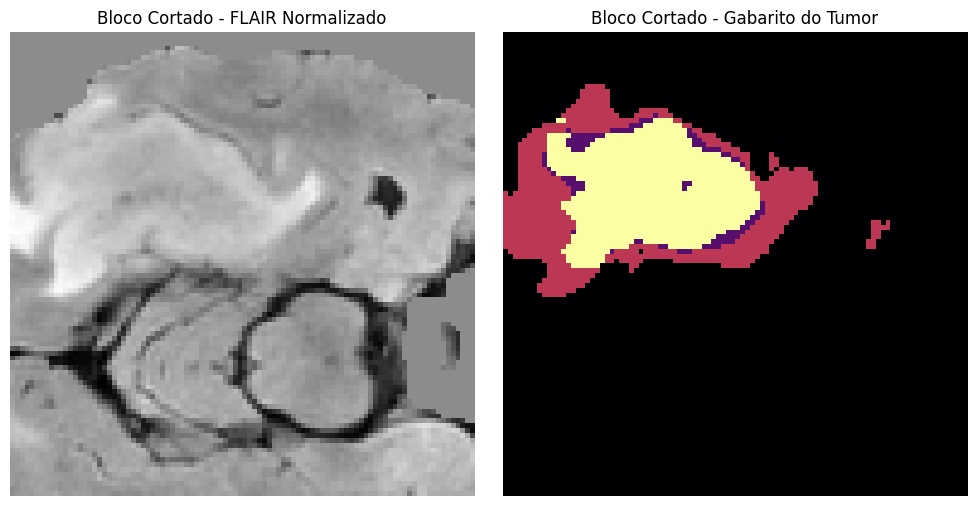

In [4]:
# Pega o primeiro lote de dados mastigados
check_data = next(iter(train_loader))

# check_data['image'] tem o formato: (Batch, Canais, X, Y, Z)
# Vamos pegar o primeiro item do batch [0], e a modalidade FLAIR (canal [0])
img_tensor = check_data["image"][0][0]
mask_tensor = check_data["label"][0][0]

print(f"Shape do Bloco de Imagem enviado para a GPU: {check_data['image'].shape}")
print(f"Shape do Bloco de Máscara enviado para a GPU: {check_data['label'].shape}")

# Pega o meio do bloco (fatia 48 de 96)
slice_idx = 48

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Bloco Cortado - FLAIR Normalizado")
plt.imshow(img_tensor[:, :, slice_idx], cmap="gray")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Bloco Cortado - Gabarito do Tumor")
plt.imshow(mask_tensor[:, :, slice_idx], cmap="inferno")
plt.axis('off')

plt.tight_layout()
plt.show()